# Treinamento e avaliação — Maceió

Este notebook implementa:
1. Definição da arquitetura ConvLSTM (3 camadas, 28 canais ocultos, kernel 3×3)
2. Treinamento com BCEWithLogitsLoss e pos_weight para lidar com esparsidade
3. Avaliação com métricas tradicionais e com tolerância espacial
4. Análise de desempenho por threshold (0,50 a 1,00)

**Entrada:** `maceio_chrono.npz`, `maceio_mask_final.npy`

**Saída:** Predições, alvos e métricas em `./output/maceio/predictions/` e `./output/maceio/perf_thrs/`

## 1. Definição da arquitetura ConvLSTM

Implementa três classes:
- **ConvLSTMCell**: Célula individual com portas (input, forget, cell, output) usando convoluções 2D
- **ConvLSTM**: Empilha múltiplas ConvLSTMCells com BatchNorm e ReLU entre camadas
- **ConvLSTMModel**: Modelo completo com ConvLSTM + Dropout + Conv2d final para predição binária

In [1]:
# Arquitetura ConvLSTM
# ConvLSTMCell: implementa as portas da LSTM usando convoluções 2D
# ConvLSTM: empilha N camadas de ConvLSTMCell com normalização
# ConvLSTMModel: modelo final com dropout e convolução de saída

import torch.nn as nn
import torch

class ConvLSTMCell(nn.Module):

    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.padding = kernel_size[0] // 2, kernel_size[1] // 2
        self.bias = bias

        self.conv = nn.Conv2d(in_channels=self.input_dim + self.hidden_dim,
                              out_channels=4 * self.hidden_dim,
                              kernel_size=self.kernel_size,
                              padding=self.padding,
                              bias=self.bias)

    def forward(self, input_tensor, cur_state):
        h_cur, c_cur = cur_state

        combined = torch.cat([input_tensor, h_cur], dim=1)  # concatenate along channel axis

        combined_conv = self.conv(combined)
        cc_i, cc_f, cc_o, cc_g = torch.split(combined_conv, self.hidden_dim, dim=1)
        i = torch.sigmoid(cc_i)
        f = torch.sigmoid(cc_f)
        o = torch.sigmoid(cc_o)
        g = torch.tanh(cc_g)

        c_next = f * c_cur + i * g
        h_next = o * torch.tanh(c_next)

        return h_next, c_next

    def init_hidden(self, batch_size, image_size):
        height, width = image_size
        return (torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device),
                torch.zeros(batch_size, self.hidden_dim, height, width, device=self.conv.weight.device))


class ConvLSTM(nn.Module):

    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, channel_last=True,
                 batch_first=False, bias=True, return_all_layers=False):
        super(ConvLSTM, self).__init__()

        self._check_kernel_size_consistency(kernel_size)

        kernel_size = self._extend_for_multilayer(kernel_size, num_layers)
        hidden_dim = self._extend_for_multilayer(hidden_dim, num_layers)
        if not len(kernel_size) == len(hidden_dim) == num_layers:
            raise ValueError('Inconsistent list length.')

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.channel_last = channel_last
        self.bias = bias
        self.return_all_layers = return_all_layers

        cell_list = []
        bn_list = []
        relu_list = []
        for i in range(0, self.num_layers):
            cur_input_dim = self.input_dim if i == 0 else self.hidden_dim[i - 1]

            cell_list.append(ConvLSTMCell(input_dim=cur_input_dim,
                                          hidden_dim=self.hidden_dim[i],
                                          kernel_size=self.kernel_size[i],
                                          bias=self.bias))
            
            relu_list.append(nn.ReLU())
            bn_list.append(nn.BatchNorm3d(self.hidden_dim[i]))

        self.cell_list = nn.ModuleList(cell_list)
        self.relu_list = nn.ModuleList(relu_list)
        self.bn_list = nn.ModuleList(bn_list)

    def forward(self, input_tensor, hidden_state=None):
        if not self.batch_first:
            input_tensor = input_tensor.permute(1, 0, 2, 3, 4)

        if self.channel_last:
            input_tensor = input_tensor.permute(0, 1, 4, 2, 3)

        b, _, _, h, w = input_tensor.size()

        if hidden_state is not None:
            raise NotImplementedError()
        else:
            hidden_state = self._init_hidden(batch_size=b, image_size=(h, w))

        layer_output_list = []
        last_state_list = []
        seq_len = input_tensor.size(1)
        cur_layer_input = input_tensor

        for layer_idx in range(self.num_layers):
            h, c = hidden_state[layer_idx]
            output_inner = []
            for t in range(seq_len):
                h, c = self.cell_list[layer_idx](input_tensor=cur_layer_input[:, t, :, :, :], cur_state=[h, c])
                output_inner.append(h)

            layer_output = torch.stack(output_inner, dim=1)
            layer_output = self.relu_list[layer_idx](layer_output)
            layer_output = self.bn_list[layer_idx](layer_output)
            #layer_output = layer_output + cur_layer_input  # Apply residual connection
            cur_layer_input = layer_output

            layer_output_list.append(layer_output)
            last_state_list.append([h, c])

        if not self.return_all_layers:
            layer_output_list = layer_output_list[-1:]
            last_state_list = last_state_list[-1:]

        return layer_output_list, last_state_list

    def _init_hidden(self, batch_size, image_size):
        init_states = []
        for i in range(self.num_layers):
            init_states.append(self.cell_list[i].init_hidden(batch_size, image_size))
        return init_states

    @staticmethod
    def _check_kernel_size_consistency(kernel_size):
        if not (isinstance(kernel_size, tuple) or
                (isinstance(kernel_size, list) and all([isinstance(elem, tuple) for elem in kernel_size]))):
            raise ValueError('`kernel_size` must be tuple or list of tuples')

    @staticmethod
    def _extend_for_multilayer(param, num_layers):
        if not isinstance(param, list):
            param = [param] * num_layers
        return param

## 2. Treinamento do modelo

Carrega os dados de `maceio_chrono.npz`, configura o modelo e executa o loop de treinamento:
- 200 épocas, batch size 252, Adam com lr=1e-5
- CosineAnnealingLR como scheduler
- BCEWithLogitsLoss com pos_weight para compensar o desbalanceamento
- Salva predições, alvos e curva de aprendizagem (train/val loss por época) ao final

In [3]:
# Treinamento do modelo ConvLSTM para Maceió
# Carrega dados, configura hiperparâmetros, executa treinamento
# Salva predições e alvos da validação em pickle

import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from torchviz import make_dot
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn.functional as F
from torch.nn.functional import one_hot
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
from sklearn.metrics import roc_curve
import os

print("Should return True if a GPU is available: ",torch.cuda.is_available())  
print("Number of GPUs available: ",torch.cuda.device_count())  
print("Name of the first GPU: ",torch.cuda.get_device_name(0)) 

from sklearn.utils import class_weight
from sklearn.metrics import mean_squared_error, mean_absolute_error, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import scipy, scipy.ndimage
import pickle
import sys
import numpy as np
import pandas as pd
# Set the seed for reproducibility
# seed = int(sys.argv[6]) # 42, 0, 123, 999
seed = 42
print("SEED: ", seed)
torch.manual_seed(seed)

# Optionally set the seed for CUDA (if using GPU)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    
# Custom worker_init_fn to ensure each worker has a different seed
def worker_init_fn(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    torch.manual_seed(worker_seed)

def get_neighbours(matrix,indices,distance):
    """
    matrix: numpy array
    indices: list with two integers
    distance: integer bigger than 1
    """
    # get indices of that element in the matrix
    indices = tuple(np.transpose(np.atleast_2d(indices)))
    # create a matrix of ones with same size as the input matrix
    dist = np.ones(np.shape(matrix))
    # put a zero at the location of the element we are looking at
    dist[indices] = 0
    # surround it by increasing numbers 1,2,3...
    dist = scipy.ndimage.distance_transform_cdt(dist, metric='chessboard')
    # get indeces of the values whoes distance is the requested (if we have more than 1, we have to add all previous)
    nb_indices = np.transpose(np.nonzero(dist == 1))
    for i in range(2,distance+1):
        nb_indices = np.concatenate((nb_indices,np.transpose(np.nonzero(dist == i))))
    return [matrix[tuple(ind)] for ind in nb_indices]


def get_custom_conf_matrix(orig,predi,dist=1):
    pred = predi.copy()
    for (i,j), value in np.ndenumerate(orig):
        if orig[i,j]==0 and pred[i,j]==0: # 0: true negative
            continue
        elif orig[i,j]==1 and pred[i,j]==1: # 1: true positive
            continue
        elif orig[i,j]==0 and pred[i,j]==1:
            if 1 in get_neighbours(orig,[i,j],dist):
                pred[i,j]=2 # 2: false positive with neighbouring positive
            else:
                pred[i,j]=3 # 3: false positive without neighbouring positive
        elif orig[i,j]==1 and pred[i,j]==0: # 4: false negative
            pred[i,j]=4

    result = pred.flatten().tolist()

    tn = result.count(0)
    tp = result.count(1)
    fp = result.count(3)
    fn = result.count(4)

    if tp==0 and result.count(2)==0:
        f1_orig = 0
        f1_new = 0
    elif tp==0:
        f1_orig = 0
        f1_new = (tp+result.count(2))/((tp+result.count(2))+0.5*(fp+fn))
    else:
        f1_orig = tp/(tp+0.5*((fp+result.count(2))+fn))
        f1_new = (tp+result.count(2))/((tp+result.count(2))+0.5*(fp+fn))

    if tp+fp+result.count(2) == 0:
        prec = 0
        prec_new = 0
    else:
        prec = tp/(tp+fp+result.count(2))
        prec_new = (tp+result.count(2))/(tp+result.count(2)+fp)
      
    if tp+fn==0:
        rec = 0
    else:  
        rec = tp/(tp+fn)
        
    if tp+result.count(2)+fn == 0:
        rec_new = 0
    else:
        rec_new = (tp+result.count(2))/(tp+result.count(2)+fn)

    return rec,prec,f1_orig,rec_new,prec_new,f1_new,pred

class ConvLSTMModel(nn.Module):
    def __init__(self, num_layers, input_chn, hidden_chn, kernel_size):
        super(ConvLSTMModel, self).__init__()
        self.num_layers = num_layers
    
        self.conv_lstm = ConvLSTM(input_chn, hidden_chn, kernel_size, num_layers, channel_last=True,
                 batch_first=True, bias=True, return_all_layers=True)
        self.final_conv = nn.Conv2d(in_channels=hidden_chn, out_channels=1, kernel_size=(3,3), padding='same')
        self.dropout = nn.Dropout(p=0.8)
    
    def forward(self, x):
        x = self.conv_lstm(x)[1][0][0] # selecting last_output, then extract sublist, then select h
        x = self.dropout(x)
        x = self.final_conv(x)
        return x

def train_model(model, train_loader, val_loader, criterion, optimizer, n_epoch, device, seed):
    best_val_loss = +float('inf')
    train_losses = []
    val_losses = []
    model.train()
    
    # Define the scheduler
    scheduler = CosineAnnealingLR(optimizer, T_max=20)
    
    for epoch in range(n_epochs):
        running_loss = 0.0
        for data, target in train_loader:
            # move data to the GPU
            data, target = data.to(device), target.to(device)
            
            # zero the parameter gradients
            optimizer.zero_grad()
            
            # forward pass
            output = model(data)
            output = torch.squeeze(output, 1) # make size match
            loss = criterion(output, target)
            
            # backward pass and optimize
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_train_loss = running_loss / len(train_loader)
        avg_val_loss, avg_rec, avg_prec, avg_f1, avg_rec_new, avg_prec_new, avg_f1_new = evaluate_model(model, val_loader, criterion, device, seed)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        print(f"Epoch {epoch}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
    return train_losses, val_losses
            
def evaluate_model(model, val_loader, criterion, device, seed):
    model.eval()
    val_loss = 0.0
    all_targets = []
    all_predictions = []
    
    with torch.no_grad():
        for data, target in val_loader:
            
            data, target = data.to(device), target.to(device)
            
            output = model(data)
            output = torch.squeeze(output, 1) # make size match
            loss = criterion(output,target) 
            val_loss += loss.item()
            
            # Collecting predictions and targets for metric calculations
            all_targets.append(target.cpu().numpy())
            all_predictions.append(output.cpu().numpy())
    
    avg_val_loss = val_loss / len(val_loader)
    
    # Concatenate all predictions and targets
    all_targets = np.concatenate(all_targets)
    all_predictions = np.concatenate(all_predictions)
    
    # put model output logits into probabilities
    all_predictions = torch.sigmoid(torch.from_numpy(all_predictions)).numpy()

    # save prediction and truth before applying threshold
    os.makedirs("./output/maceio/predictions/", exist_ok=True)
    with open(f"./output/maceio/predictions/convlstm_predictions_maceio_{seed}.pkl", "wb") as f_p:  
        pickle.dump(all_predictions, f_p)
    with open(f"./output/maceio/predictions/convlstm_targets_maceio_{seed}.pkl", "wb") as f_t:  
        pickle.dump(all_targets, f_t)
    print("Saved final predictions and targets!")
    
    # apply thr to go from probability to class number
    thr=0.5
    all_predictions[all_predictions >= thr] = 1
    all_predictions[all_predictions < thr] = 0
    
    # Initialize lists to store metrics for each sample
    f1_list = []
    f1_new_list = []
    rec_list = []
    prec_list = []
    rec_new_list = []
    prec_new_list = []
    # Loop over each sample
    for i in range(np.shape(all_predictions)[0]):
        pred_flat = all_predictions[i,:] 
        true_flat = all_targets[i,:] 
        
        rec,prec,f1,rec_new,prec_new,f1_new,pred = get_custom_conf_matrix(true_flat,pred_flat,dist=1)
     
        rec_list.append(rec)
        prec_list.append(prec)
        f1_list.append(f1)
        rec_new_list.append(rec_new)
        prec_new_list.append(prec_new)
        f1_new_list.append(f1_new)
    
    # Compute the average precision, recall, and f1 score across all samples and classes
    avg_prec = np.mean(prec_list)
    avg_rec = np.mean(rec_list)
    avg_f1 = np.mean(f1_list)
    avg_prec_new = np.mean(prec_new)
    avg_rec_new = np.mean(rec_new)
    avg_f1_new = np.mean(f1_new)

    return avg_val_loss, avg_rec, avg_prec, avg_f1, avg_rec_new, avg_prec_new, avg_f1_new

def select_features(x_train,x_val):
    # keep only C channel
    x_train = x_train[:,:,:,:,0]
    x_val = x_val[:,:,:,:,0]
    x_train = np.expand_dims(x_train, axis=-1)
    x_val = np.expand_dims(x_val, axis=-1)
    return (torch.from_numpy(x_train),torch.from_numpy(x_val))


def main(batch_size, n_epochs, num_layers, input_chn, hidden_chn, kernel_size, seed):
    # load the data as tensors
    data = np.load(f'./output/maceio/maceio_chrono.npz')
    x_train = torch.from_numpy(data['x_train']).float() 
    y_train = torch.from_numpy(data['y_train']).float()
    i_train = data['i_train']
    x_val = torch.from_numpy(data['x_val']).float()
    y_val = torch.from_numpy(data['y_val']).float()
    i_val = data['i_val']
    
    # Shuffle training data
    train_indices = np.random.permutation(x_train.shape[0])
    x_train = x_train[train_indices]
    y_train = y_train[train_indices]
    i_train = i_train[train_indices]

    # Shuffle validation data
    val_indices = np.random.permutation(x_val.shape[0])
    x_val = x_val[val_indices]
    y_val = y_val[val_indices]
    i_val = i_val[val_indices]
    
    # truncate to largest multiple of batch_size for consistent batching
    n_train = (x_train.shape[0] // batch_size) * batch_size
    n_val = (x_val.shape[0] // batch_size) * batch_size
    x_train = x_train[:n_train]
    y_train = y_train[:n_train]
    i_train = i_train[:n_train]
    x_val = x_val[:n_val]
    y_val = y_val[:n_val]
    i_val = i_val[:n_val]
    
    # Setting all NaN values to 0 (since they have been correctly identified already)
    x_train[torch.isnan(x_train)] = 0
    y_train[torch.isnan(y_train)] = 0
    x_val[torch.isnan(x_val)] = 0
    y_val[torch.isnan(y_val)] = 0
    
    # keep only the C (crime) channel
    x_train = x_train[:,:,:,:,0]
    x_val = x_val[:,:,:,:,0]
    x_train = np.expand_dims(x_train, axis=-1)
    x_val = np.expand_dims(x_val, axis=-1)
    x_train, x_val = (torch.from_numpy(x_train),torch.from_numpy(x_val))
    
    print(f"Shapes: {np.shape(x_train)} {np.shape(y_train)}")
    print(f"Shapes: {np.shape(x_val)} {np.shape(y_val)}")
    
    # remove channel dimension so it will work at the end
    y_train = y_train.permute(0, 3, 1, 2)
    y_val = y_val.permute(0, 3, 1, 2)
    y_train = torch.squeeze(y_train, 1)
    y_val = torch.squeeze(y_val, 1)
    
    # define the device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # data loaders
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True,worker_init_fn=worker_init_fn)
    test_loader = DataLoader(TensorDataset(x_val, y_val), batch_size=batch_size, shuffle=False)

    # Model
    model = ConvLSTMModel(num_layers, input_chn, hidden_chn, kernel_size)
    print(model)
    total_params = sum(p.numel() for p in model.parameters())
    print(f'Total number of parameters: {total_params}')  
    model.to(device) # to work on GPU
    
    # Calculate class weights
    # O que .view(-1) faz: "achata" (flatten) o tensor multidimensional em um vetor 1D, sem copiar memória. É como pegar todos os números e enfileirá-los.
    # Se você tem, digamos, 36.000 amostras, cada uma com 256 células:
    # y_train: shape (36000, 16, 16) → 9.216.000 números
    # targets_flat: shape (9216000,)  → mesmos números em fila    
    targets_flat = y_train.view(-1)  # Flatten targets to (n_samples * 16 * 16)

    # Calculate the number of positive and negative examples
    num_positives = targets_flat.sum().item()
    num_negatives = targets_flat.size(0) - num_positives

    pos_weight = num_negatives / num_positives # Calculate pos_weight for the positive class

    # Convert pos_weight to a PyTorch tensor
    pos_weight_tensor = torch.tensor(pos_weight).float().to(device) # targets.device
    print("pos_weight_tensor: ",pos_weight_tensor)
    print([1, pos_weight_tensor.cpu().item()])
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor) 
    optimizer = optim.Adam(model.parameters(), lr=0.00001) 
    
    print("Training model...") 
    train_losses, val_losses = train_model(model, train_loader, test_loader, criterion, optimizer, n_epochs, device, seed)

    # Save learning curve (train/val loss per epoch)
    os.makedirs("./output/maceio/predictions/", exist_ok=True)
    with open(f"./output/maceio/predictions/convlstm_losses_maceio_{seed}.pkl", "wb") as f:
        pickle.dump({"train": train_losses, "val": val_losses}, f)
    print(f"Saved learning curve to ./output/maceio/predictions/convlstm_losses_maceio_{seed}.pkl")

    # save index of subgrids used
    with open(f"./output/maceio/predictions/convlstm_i_maceio__{seed}.pkl", "wb") as f:  
        pickle.dump(i_val, f)
    
# params data loading
seq_length = 29

# params architecture model
num_layers = 3
hidden_chn = seq_length-1 #needs to match sequence legth (so LB-1)
kernel_size = (3,3)

input_chn = 1

# params training
batch_size = 252
n_epochs = 200

print(f"Settings: n_epochs={n_epochs}, batch_size={batch_size}, num_layers={num_layers}, hidden_chn={hidden_chn}")
main(batch_size, n_epochs, num_layers, input_chn, hidden_chn, kernel_size, seed)

Should return True if a GPU is available:  True
Number of GPUs available:  1
Name of the first GPU:  NVIDIA GeForce RTX 4070 Laptop GPU
SEED:  42
Settings: n_epochs=200, batch_size=252, num_layers=3, hidden_chn=28
Shapes: torch.Size([32508, 28, 16, 16, 1]) torch.Size([32508, 16, 16, 1])
Shapes: torch.Size([3024, 28, 16, 16, 1]) torch.Size([3024, 16, 16, 1])
ConvLSTMModel(
  (conv_lstm): ConvLSTM(
    (cell_list): ModuleList(
      (0): ConvLSTMCell(
        (conv): Conv2d(29, 112, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
      (1-2): 2 x ConvLSTMCell(
        (conv): Conv2d(56, 112, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (relu_list): ModuleList(
      (0-2): 3 x ReLU()
    )
    (bn_list): ModuleList(
      (0-2): 3 x BatchNorm3d(28, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (final_conv): Conv2d(28, 1, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (dropout): Dropout(p=0.8, inplace=False)
)
Total numb

## 3. Avaliação por threshold

Calcula métricas de desempenho para 51 thresholds (0,50 a 1,00):
- **Métricas tradicionais**: recall, precision, F1 (célula exata)
- **Métricas com tolerância espacial**: considera acerto se o crime real está em uma célula vizinha (distância de Chebyshev ≤ 1)

A máscara de validade é aplicada para ignorar células fora do município.

In [4]:
# Avaliação por threshold com métricas tradicionais e espaciais
# get_custom_conf_matrix(): calcula TP, FP, FN com e sem tolerância espacial
# Varre thresholds de 0.50 a 1.00 em passos de 0.01
# Salva resultados em pickle para análise posterior

import numpy as np
import pickle
import sys
from sklearn.metrics import confusion_matrix
import scipy.ndimage
import os

def get_neighbours(matrix, indices, distance, mask=None):
    """
    matrix: numpy array
    indices: list with two integers
    distance: integer >= 1
    mask: optional mask (1 = valid, 0 = invalid)
    """
    indices = tuple(np.transpose(np.atleast_2d(indices)))
    dist = np.ones(np.shape(matrix))
    dist[indices] = 0

    dist = scipy.ndimage.distance_transform_cdt(dist, metric='chessboard')
    nb_indices = np.transpose(np.nonzero(dist == 1))
    for i in range(2, distance + 1):
        nb_indices = np.concatenate((nb_indices, np.transpose(np.nonzero(dist == i))))

    neighbours = []
    for ind in nb_indices:
        i, j = ind
        if 0 <= i < matrix.shape[0] and 0 <= j < matrix.shape[1]:
            if mask is None or mask[i, j] == 1:  # only use valid cells
                neighbours.append(matrix[i, j])
    return neighbours


def get_custom_conf_matrix(orig, predi, dist=1, mask=None):
    pred = predi.copy()
    for (i, j), value in np.ndenumerate(orig):
        if mask is not None and mask[i, j] == 0:
            continue  # skip masked cells 
        if orig[i, j] == 0 and pred[i, j] == 0:  # TN
            continue
        elif orig[i, j] == 1 and pred[i, j] == 1:  # TP
            continue
        elif orig[i, j] == 0 and pred[i, j] == 1:
            if 1 in get_neighbours(orig, [i, j], dist, mask=mask):
                pred[i, j] = 2  # FP with neighboring crime
            else:
                pred[i, j] = 3  # FP with no neighbor
        elif orig[i, j] == 1 and pred[i, j] == 0:  # FN
            pred[i, j] = 4

    result = pred[mask == 1].flatten().tolist() if mask is not None else pred.flatten().tolist()
    
    tn = result.count(0)
    tp = result.count(1)
    fp = result.count(3)
    fn = result.count(4)
    fp_nb = result.count(2)

    # F1 & Precision/Recall handling
    if tp == 0 and fp_nb == 0:
        f1_orig = f1_new = 0
    elif tp == 0:
        f1_orig = 0
        f1_new = (tp + fp_nb) / ((tp + fp_nb) + 0.5 * (fp + fn))
    else:
        f1_orig = tp / (tp + 0.5 * ((fp + fp_nb) + fn))
        f1_new = (tp + fp_nb) / ((tp + fp_nb) + 0.5 * (fp + fn))

    if tp + fp + fp_nb == 0:
        prec = prec_new = 0
    else:
        prec = tp / (tp + fp + fp_nb)
        prec_new = (tp + fp_nb) / (tp + fp_nb + fp)

    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    rec_new = (tp + fp_nb) / (tp + fp_nb + fn) if (tp + fp_nb + fn) > 0 else 0

    return rec, prec, f1_orig, rec_new, prec_new, f1_new, pred

def calculate_performance_per_threhold(seed):
    full_mask = np.load(f"./output/maceio/maceio_mask_final.npy") # i think mask is not necessary for these metrics

    with open(f"./output/maceio/predictions/convlstm_i_maceio__{seed}.pkl", 'rb') as f:
        subgrid_indices = pickle.load(f)

    with open(f"./output/maceio/predictions/convlstm_predictions_maceio_{seed}.pkl", 'rb') as file:
        data_pred = pickle.load(file)

    with open(f"./output/maceio/predictions/convlstm_targets_maceio_{seed}.pkl", 'rb') as file:
        data_orig = pickle.load(file)
        
    print("All data opened!")

    originals = data_orig
    predictions = data_pred

    assert len(subgrid_indices) == predictions.shape[0], "Mismatch between subgrid indices and number of samples"

    
    perf_list = []

    for thr in np.arange(0.50, 1.01, 0.01):
        rec_list, prec_list, f1_list = [], [], []
        rec_new_list, prec_new_list, f1_new_list = [], [], []

        for sample in range(predictions.shape[0]):
            origi = originals[sample]
            predi = predictions[sample]
            predi2 = (predi >= thr).astype(int)

            top_i, top_j = subgrid_indices[sample]
            mask_subgrid = full_mask[top_i:top_i + 16, top_j:top_j + 16] 
                
            rec, prec, f1, rec_new, prec_new, f1_new, _ = get_custom_conf_matrix(
                origi, predi2, dist=1, mask=mask_subgrid
            )

            rec_list.append(rec)
            prec_list.append(prec)
            f1_list.append(f1)
            rec_new_list.append(rec_new)
            prec_new_list.append(prec_new)
            f1_new_list.append(f1_new)

        perf_list.append([
            thr,
            np.mean(rec_list), np.mean(prec_list), np.mean(f1_list),
            np.mean(rec_new_list), np.mean(prec_new_list), np.mean(f1_new_list)
        ])

    os.makedirs("./output/maceio/perf_thrs", exist_ok=True)
    output_path = f"./output/maceio/perf_thrs/convlstm_perf_thrs_maceio_{seed}.pkl"
    with open(output_path, "wb") as fp:
        pickle.dump(perf_list, fp)
    print(f"Saved performance metrics to {output_path}")
    
calculate_performance_per_threhold(seed = 42)

All data opened!
Saved performance metrics to ./output/maceio/perf_thrs/convlstm_perf_thrs_maceio_42.pkl


## 4. Visualização dos resultados

Carrega e exibe as métricas de desempenho por threshold.

In [5]:
# Carrega e exibe as métricas salvas

import pickle
import pandas as pd
with open("./output/maceio/perf_thrs/convlstm_perf_thrs_maceio_42.pkl", "rb") as f:
    perf_data = pickle.load(f)
# Check what type it is and display it
print(type(perf_data))
if isinstance(perf_data, dict):
    for k, v in perf_data.items():
        print(f"{k}: {v}")
elif isinstance(perf_data, (pd.DataFrame, pd.Series)):
    display(perf_data)
else:
    display(perf_data)

<class 'list'>


[[np.float64(0.5),
  np.float64(0.6501897518266566),
  np.float64(0.02015134371432665),
  np.float64(0.03779901108528593),
  np.float64(0.7899490061679805),
  np.float64(0.1404982141838588),
  np.float64(0.22354832138023553)],
 [np.float64(0.51),
  np.float64(0.6370008188460569),
  np.float64(0.020404096125710373),
  np.float64(0.03825929949731687),
  np.float64(0.7802556770278977),
  np.float64(0.14242814476454796),
  np.float64(0.2252566558862886)],
 [np.float64(0.52),
  np.float64(0.622869425547997),
  np.float64(0.020795362167982032),
  np.float64(0.03879608158674064),
  np.float64(0.7703157941326735),
  np.float64(0.14406811209192893),
  np.float64(0.22665258900268268)],
 [np.float64(0.53),
  np.float64(0.6062523620559335),
  np.float64(0.02095741503748369),
  np.float64(0.039032368310421665),
  np.float64(0.7601329908555577),
  np.float64(0.14502154666390338),
  np.float64(0.22729329855925168)],
 [np.float64(0.54),
  np.float64(0.5911785084404132),
  np.float64(0.0210713646106887

## 5. Análise detalhada

Exibe os resultados em formato de tabela e identifica os melhores thresholds.

In [6]:
# Exibe resultados em DataFrame e identifica os melhores thresholds
# para F1 tradicional e F1 espacial

import pickle
import pandas as pd
with open("./output/maceio/perf_thrs/convlstm_perf_thrs_maceio_42.pkl", "rb") as f:
    perf_list = pickle.load(f)
df_perf = pd.DataFrame(perf_list, columns=[
    "threshold", "recall", "precision", "f1",
    "recall_spatial", "precision_spatial", "f1_spatial"
])
display(df_perf)
# Find best threshold by F1
best_row = df_perf.loc[df_perf["f1_spatial"].idxmax()]
print(f"\nBest threshold: {best_row['threshold']:.2f}")
print(f"  Recall (spatial):    {best_row['recall_spatial']:.4f}")
print(f"  Precision (spatial): {best_row['precision_spatial']:.4f}")
print(f"  F1 (spatial):        {best_row['f1_spatial']:.4f}")

,threshold,recall,precision,f1,recall_spatial,precision_spatial,f1_spatial
0,0.50,0.650190,0.020151,0.037799,0.789949,0.140498,0.223548
1,0.51,0.637001,0.020404,0.038259,0.780256,0.142428,0.225257
2,0.52,0.622869,0.020795,0.038796,0.770316,0.144068,0.226653
3,0.53,0.606252,0.020957,0.039032,0.760133,0.145022,0.227293
4,0.54,0.591179,0.021071,0.039220,0.749436,0.146189,0.228134
5,0.55,0.574688,0.021354,0.039665,0.736364,0.147210,0.229336
6,0.56,0.554175,0.021323,0.039888,0.723143,0.148287,0.230431
7,0.57,0.538467,0.021815,0.040622,0.712958,0.150765,0.232495
8,0.58,0.521450,0.021648,0.040470,0.700056,0.152832,0.233840
9,0.59,0.500209,0.021809,0.040643,0.686063,0.153934,0.234724



Best threshold: 0.68
  Recall (spatial):    0.5414
  Precision (spatial): 0.1710
  F1 (spatial):        0.2405


## 6. Curva de aprendizagem

Carrega `convlstm_losses_maceio_{seed}.pkl` e plota train loss × val loss por época. Útil para avaliar se 200 épocas faz sentido — se a val loss platôa cedo, vale considerar early stopping; se ainda está caindo no fim, o treino merece mais épocas.

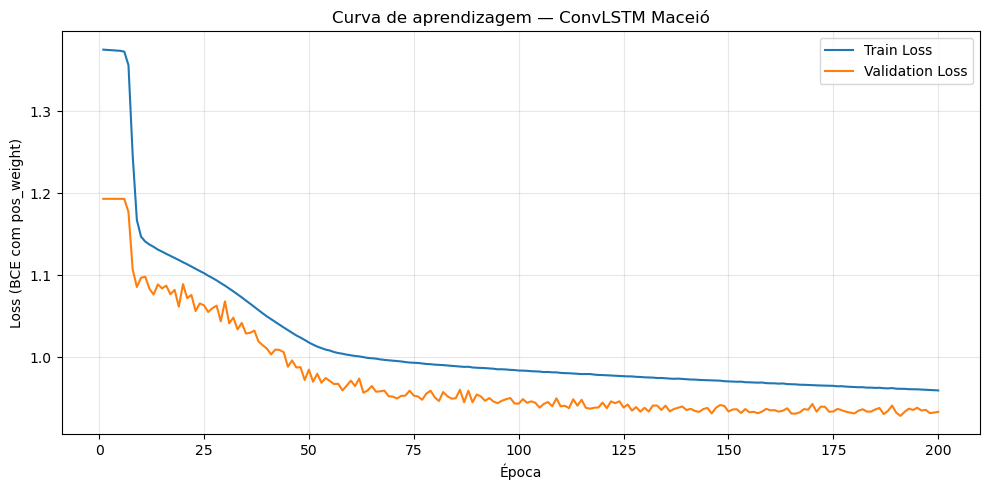

Melhor época (menor val loss): 191 de 200
Val loss mínimo:  0.9281
Val loss final:   0.9331
Train loss final: 0.9592

→ Val loss ainda caindo no fim. Vale tentar mais épocas.


In [7]:
# Carrega e plota a curva de aprendizagem (train/val loss por época)

import pickle
import numpy as np
import matplotlib.pyplot as plt

with open("./output/maceio/predictions/convlstm_losses_maceio_42.pkl", "rb") as f:
    losses = pickle.load(f)

train = losses["train"]
val = losses["val"]
epochs = range(1, len(train) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(epochs, train, label="Train Loss", linewidth=1.5)
ax.plot(epochs, val, label="Validation Loss", linewidth=1.5)
ax.set_xlabel("Época")
ax.set_ylabel("Loss (BCE com pos_weight)")
ax.set_title("Curva de aprendizagem — ConvLSTM Maceió")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# Diagnóstico textual
best_epoch = int(np.argmin(val)) + 1
print(f"Melhor época (menor val loss): {best_epoch} de {len(val)}")
print(f"Val loss mínimo:  {min(val):.4f}")
print(f"Val loss final:   {val[-1]:.4f}")
print(f"Train loss final: {train[-1]:.4f}")

# Interpretação grosseira
gap = abs(train[-1] - val[-1])
if best_epoch < len(val) * 0.7:
    print(f"\n→ Val loss melhorou até a época {best_epoch} e depois piorou. Considere early stopping.")
elif best_epoch >= len(val) - 10:
    print(f"\n→ Val loss ainda caindo no fim. Vale tentar mais épocas.")
else:
    print(f"\n→ Treino aparentemente convergiu próximo do fim. 200 épocas parece adequado.")
if gap > 0.1 * abs(val[-1]):
    print(f"→ Gap entre train e val loss notável ({gap:.4f}); pode haver overfitting.")